# Otimização de Portfólio Multiobjetivo (Risco-Retorno-ESG) — Checkpoint 2

Este notebook estende o primeiro notebook mono-objetivo com o
terceiro objetivo ESG e resolve o problema com dois algoritmos evolutivos
multiobjetivo, **NSGA-II** e **SPEA-II**. Define toda a modelagem, os dois MOEAs, o DE mono-objetivo
de referência, os baselines e as análises inline.

## 1. Formulação do problema multiobjetivo

**Variável de decisão e restrições.** Idênticas a formulação do com objetivo único: um vetor de
pesos $w \in \mathbb{R}^N$ ($N$ ativos), sujeito a

$$\sum_{i=1}^{N} w_i = 1, \qquad 0 \le w_i \le w_{\max} \quad \forall i$$

(carteira totalmente investida, *long-only*, com teto de concentração
$w_{\max}$ por ativo).

**Três componentes objetivo (forma de minimização).**

$$f_1(w) = -\mu^\top w \qquad \text{(retorno esperado, negado)}$$

$$f_2(w) = w^\top \Sigma w \qquad \text{(risco — variância do portfólio)}$$

$$f_3(w) = -e^\top w \qquad \text{(score ESG, negado)}$$

onde $e \in \mathbb{R}^N$ é um vetor de scores ESG por ativo.

**Dominância de Pareto.** Diferente do CP1 (que escalariza $f_1,f_2$ em um
único $g(w)$), aqui **não escalarizamos** os três objetivos — cada carteira
$w$ é avaliada pelo vetor $(f_1,f_2,f_3)$ e comparamos carteiras por
dominância: $w_a$ **domina** $w_b$ se $f_i(w_a) \le f_i(w_b)$ para todo $i$ e
$f_i(w_a) < f_i(w_b)$ para ao menos um $i$. Uma carteira é **Pareto-ótima**
(pertence à fronteira) se nenhuma outra carteira factível a domina. O produto
de NSGA-II/SPEA-II não é uma única carteira, mas uma **aproximação da
fronteira de Pareto** — um conjunto de carteiras representando trade-offs
diferentes entre retorno, risco e ESG.

**Por que normalizar os objetivos antes de otimizar, se não há
escalarização?** $f_1$ (~$[-0{,}4, 0{,}4]$), $f_2$ (~$[0{,}01, 0{,}04]$) e
$f_3$ (ESG negado, ~$[-100, 0]$) têm escalas muito diferentes. Isso não muda
o *ranking* por dominância (Pareto não depende de escala), mas afeta dois
mecanismos que SIM dependem de distância/volume no espaço de objetivos:

- O **SPEA-II** estima densidade por distância euclidiana ao $k$-ésimo
  vizinho mais próximo no espaço de objetivos — sem normalizar, $f_3$
  dominaria essa distância inteiramente, fazendo o algoritmo ignorar
  diversidade em $f_1,f_2$.
- O **hipervolume** é um volume no espaço de objetivos — sem normalizar, seria quase
  todo explicado pela dimensão de maior escala, tornando comparações entre
  algoritmos/sementes pouco informativas.

Por isso aplicamos a mesma estratégia de normalização z-score do CP1, estendida para 3 componentes, **antes** de entrar nos MOEAs. Para
relatório e figuras, sempre voltamos às unidades originais (retorno %, risco
como volatilidade, score ESG 0–100) — nunca aos objetivos normalizados
internos do pymoo.

**Comparação com a versão single-objective.** Reexecutamos o Differential
Evolution mono-objetivo do CP1 sobre os MESMOS dados ($\mu,\Sigma$)
desta execução — o DE não conhece $f_3$/ESG, exatamente como no CP1 — e
mapeamos a carteira encontrada no espaço de 3 objetivos para comparar com a
fronteira de Pareto.

**Baselines.** $1/N$ e random search (mesmo orçamento total de avaliações dos
MOEAs), reduzidos ao subconjunto não-dominado.

**Fronteira de Pareto inicial.** A população inicial de cada MOEA (já
reparada para ser factível, mas sem nenhuma geração de busca) também tem uma
fronteira não-dominada — comparamos essa fronteira "ingênua" à fronteira
final, para evidenciar o progresso da busca evolutiva.

## 2. Setup: imports, configuração e sementes

Mesmas bibliotecas do CP1, mais os algoritmos multiobjetivo do `pymoo`
(`NSGA2`, `SPEA2`), o indicador de hipervolume (`HV`) e a ordenação por
não-dominância (`NonDominatedSorting`). A célula `CONFIG` é a única que
precisa ser editada para reproduzir com outros parâmetros.

In [ ]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.covariance import LedoitWolf

from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.spea2 import SPEA2
from pymoo.core.callback import Callback
from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.indicators.hv import HV
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")


CONFIG = {
    "tickers": [
        "PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "BBAS3.SA", "ITSA4.SA",
        "ABEV3.SA", "WEGE3.SA", "RENT3.SA", "SUZB3.SA", "GGBR4.SA", "CSNA3.SA",
        "CMIG4.SA", "EQTL3.SA", "RADL3.SA", "LREN3.SA", "B3SA3.SA", "PRIO3.SA",
        "HAPV3.SA", "TOTS3.SA", "RAIL3.SA", "SBSP3.SA", "VIVT3.SA", "KLBN11.SA",
    ],
    "data_fim": "today",
    "anos_historico": 5,
    "pregoes_por_ano": 252,
    "usar_ledoit_wolf": True,
    "cache_dir": Path("../data_cache"),  
    "usar_cache": True,
    "w_min": 0.0,
    "w_max": 0.20,
    "semente_esg": 2024,
    "score_min_esg": 0.0,
    "score_max_esg": 100.0,
    # Normalização (z-score) dos 3 objetivos antes de entrar nos MOEAs
    "n_amostras_normalizacao": 5000,
    "semente_normalizacao": 123,
    # NSGA-II / SPEA-II (mesmo pop_size/n_gen nos dois, para isolar o efeito
    # do mecanismo de seleção/diversidade, não do orçamento)
    "nsga2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    "spea2": {"pop_size": 100, "n_gen": 150, "eliminate_duplicates": True},
    # Hipervolume: ponto de referência fixo no espaço NORMALIZADO dos objetivos
    "k_desvios_ref_point": 4.0,
    # DE mono-objetivo (CP1) — mesmos parâmetros/lambdas, para o ponto de comparação
    "lambda1": 0.5,
    "lambda2": 0.5,
    "de": {"pop_size": 80, "n_gen": 150, "variant": "DE/rand/1/bin", "CR": 0.9, "F": 0.8},
    "taxa_livre_risco": 0.0,
    "sementes": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
}

n_tickers = len(CONFIG["tickers"])
n_sementes = len(CONFIG["sementes"])
print(f"{n_tickers} ativos configurados; {n_sementes} sementes: {CONFIG['sementes']}")


24 ativos configurados; 10 sementes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 3. Carregamento de dados (yfinance) e estimação de $\mu$ e $\Sigma$

Idêntico ao CP1 (mesmos tickers, mesma janela, mesmo cache local) — garante
que o DE mono-objetivo e os MOEAs operem sobre exatamente
os mesmos $\mu,\Sigma$ nesta execução, como pedido na comparação do
enunciado.

In [2]:
def resolver_datas(data_fim: str, anos_historico: int) -> tuple[str, str]:
    """Resolve a janela [inicio, fim] de download. "today" usa a data de execução."""
    fim = datetime.today() if data_fim == "today" else datetime.strptime(data_fim, "%Y-%m-%d")
    inicio = fim - timedelta(days=int(365.25 * anos_historico))
    return inicio.strftime("%Y-%m-%d"), fim.strftime("%Y-%m-%d")


def baixar_precos(
    tickers: list[str], data_fim: str, anos_historico: int, cache_dir: Path, usar_cache: bool
) -> pd.DataFrame:
    """Baixa preços de fechamento ajustado, com cache local em CSV."""
    inicio, fim = resolver_datas(data_fim, anos_historico)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    chave = "_".join(t.replace(".", "") for t in sorted(tickers))
    caminho_cache = cache_dir / f"precos_{chave}_{inicio}_{fim}.csv"

    if usar_cache and caminho_cache.exists():
        precos = pd.read_csv(caminho_cache, index_col=0, parse_dates=True)
        if set(tickers).issubset(set(precos.columns)):
            return precos[tickers]

    dados_brutos = yf.download(tickers, start=inicio, end=fim, auto_adjust=True, progress=False, group_by="column")
    if isinstance(dados_brutos.columns, pd.MultiIndex):
        precos = dados_brutos["Close"]
    else:
        precos = dados_brutos[["Close"]]
        precos.columns = tickers
    precos = precos[tickers].dropna(how="all").ffill().dropna(how="any")

    if usar_cache:
        precos.to_csv(caminho_cache)
    return precos


def estimar_mu_sigma(
    retornos_diarios: pd.DataFrame, pregoes_por_ano: int, usar_ledoit_wolf: bool
) -> tuple[np.ndarray, np.ndarray]:
    """mu = média amostral anualizada; Sigma = covariância amostral (ou Ledoit-Wolf) anualizada."""
    mu = retornos_diarios.mean().to_numpy() * pregoes_por_ano
    if usar_ledoit_wolf:
        sigma_diaria = LedoitWolf().fit(retornos_diarios.to_numpy()).covariance_
    else:
        sigma_diaria = np.cov(retornos_diarios.to_numpy(), rowvar=False)
    sigma = sigma_diaria * pregoes_por_ano
    return mu, sigma


precos = baixar_precos(
    CONFIG["tickers"], CONFIG["data_fim"], CONFIG["anos_historico"], CONFIG["cache_dir"], CONFIG["usar_cache"]
)
retornos_diarios = precos.pct_change().dropna(how="any")
mu, sigma = estimar_mu_sigma(retornos_diarios, CONFIG["pregoes_por_ano"], CONFIG["usar_ledoit_wolf"])
n_ativos = len(CONFIG["tickers"])

print(f"Preços: {precos.shape[0]} pregões x {precos.shape[1]} ativos.")
print(f"mu (retorno esperado anual): min={mu.min():.3f}, média={mu.mean():.3f}, max={mu.max():.3f}")
print(f"Sigma (covariância anual): diagonal min={np.diag(sigma).min():.4f}, max={np.diag(sigma).max():.4f}")


Preços: 1246 pregões x 24 ativos.
mu (retorno esperado anual): min=-0.425, média=0.080, max=0.358
Sigma (covariância anual): diagonal min=0.0499, max=0.3818


## 4. Objetivos multiobjetivo, ESG sintético, restrições e normalização 3D

Reativa o terceiro objetivo ($f_3$, ESG) isolado desde o CP1 e estende a
normalização z-score para 3 componentes. A projeção no capped-simplex
(reparo de factibilidade) é idêntica à do CP1 — a restrição $\sum w_i=1$ não
depende do número de objetivos.

In [3]:
def f1_retorno(w: np.ndarray, mu: np.ndarray) -> float:
    """f1(w) = -mu^T w (retorno esperado, negado para minimização)."""
    return float(-mu @ w)


def f2_risco(w: np.ndarray, sigma: np.ndarray) -> float:
    """f2(w) = w^T Sigma w (variância do portfólio)."""
    return float(w @ sigma @ w)


def gerar_esg_sintetico(tickers: list[str], semente_esg: int, score_min: float, score_max: float) -> np.ndarray:
    """Vetor ESG sintético e reprodutível — PLACEHOLDER (ver Seção 1: sem fonte real de dados ESG)."""
    rng = np.random.default_rng(semente_esg)
    return rng.uniform(score_min, score_max, size=len(tickers))


def f3_esg(w: np.ndarray, esg: np.ndarray) -> float:
    """f3(w) = -e^T w (score ESG da carteira, negado para minimização)."""
    return float(-esg @ w)


def score_esg_carteira(w: np.ndarray, esg: np.ndarray) -> float:
    """Score ESG médio (ponderado pelos pesos), em [score_min, score_max] — métrica de relatório."""
    return float(esg @ w)


def avaliar_componentes_mo(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray) -> np.ndarray:
    """Vetor (f1, f2, f3) bruto (não normalizado) dos 3 objetivos do Checkpoint 2."""
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma), f3_esg(w, esg)])


def projetar_capped_simplex(
    v: np.ndarray, w_min: float, w_max: float, tol: float = 1e-10, max_iter: int = 100
) -> np.ndarray:
    """Projeta v no capped-simplex {w : soma(w)=1, w_min<=w_i<=w_max} por bisseção em tau (ver CP1, Seção 4)."""
    v = np.asarray(v, dtype=float)
    n = v.shape[0]
    if n * w_min - 1 > tol or 1 - n * w_max > tol:
        raise ValueError(f"Capped simplex infactível para N={n}, w_min={w_min}, w_max={w_max}.")

    tau_lo, tau_hi = v.min() - w_max, v.max() - w_min

    def soma_clip(tau: float) -> float:
        return np.clip(v - tau, w_min, w_max).sum()

    for _ in range(max_iter):
        tau_mid = 0.5 * (tau_lo + tau_hi)
        s = soma_clip(tau_mid)
        if abs(s - 1.0) <= tol:
            tau_lo = tau_hi = tau_mid
            break
        if s > 1.0:
            tau_lo = tau_mid
        else:
            tau_hi = tau_mid

    tau = 0.5 * (tau_lo + tau_hi)
    w = np.clip(v - tau, w_min, w_max)

    residuo = 1.0 - w.sum()
    if abs(residuo) > 0:
        livres = (w > w_min + 1e-12) & (w < w_max - 1e-12)
        if livres.any():
            w[livres] += residuo / livres.sum()
        else:
            w += residuo / n
        w = np.clip(w, w_min, w_max)
    return w


def checar_factibilidade(w: np.ndarray, w_min: float, w_max: float, tol: float = 1e-6) -> bool:
    """Confere soma(w)=1 e w_min<=w_i<=w_max dentro de uma tolerância numérica."""
    return abs(w.sum() - 1.0) <= tol and bool(np.all(w >= w_min - tol) and np.all(w <= w_max + tol))


def amostrar_carteiras_aleatorias(n_amostras: int, n_ativos: int, w_min: float, w_max: float, semente: int) -> np.ndarray:
    """Amostra carteiras factíveis i.i.d.: vetores gaussianos projetados no capped-simplex."""
    rng = np.random.default_rng(semente)
    candidatos = rng.normal(size=(n_amostras, n_ativos))
    return np.array([projetar_capped_simplex(c, w_min, w_max) for c in candidatos])


@dataclass
class EstatisticasNormalizacaoMO:
    media: np.ndarray  # shape (3,)
    desvio: np.ndarray  # shape (3,)


def calcular_estatisticas_normalizacao_mo(
    mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray, w_min: float, w_max: float, n_amostras: int, semente: int
) -> EstatisticasNormalizacaoMO:
    """Estima média/desvio de (f1, f2, f3) sobre uma amostra de carteiras aleatórias factíveis."""
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    componentes = np.array([avaliar_componentes_mo(w, mu, sigma, esg) for w in carteiras])
    media = componentes.mean(axis=0)
    desvio = componentes.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoMO(media=media, desvio=desvio)


def normalizar_mo(f: np.ndarray, stats: EstatisticasNormalizacaoMO) -> np.ndarray:
    """Normaliza (z-score) o vetor de objetivos f usando as estatísticas de referência."""
    return (f - stats.media) / stats.desvio


def f_objetivos_normalizados(
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray, stats: EstatisticasNormalizacaoMO
) -> np.ndarray:
    """(f1, f2, f3) bruto -> normalizado. É isto que os MOEAs recebem como objetivo."""
    return normalizar_mo(avaliar_componentes_mo(w, mu, sigma, esg), stats)


esg = gerar_esg_sintetico(CONFIG["tickers"], CONFIG["semente_esg"], CONFIG["score_min_esg"], CONFIG["score_max_esg"])
STATS_MO = calcular_estatisticas_normalizacao_mo(
    mu, sigma, esg, CONFIG["w_min"], CONFIG["w_max"], CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"]
)
# Objetivos normalizados têm média 0 e desvio 1 por construção (z-score) — um
# ponto de referência fixo k desvios-padrão acima da média já é pior que
# praticamente toda carteira factível, em qualquer escala original.
REF_POINT = np.full(3, CONFIG["k_desvios_ref_point"])

print(f"Vetor ESG sintético: min={esg.min():.1f}, média={esg.mean():.1f}, max={esg.max():.1f}")
print(f"Estatísticas de normalização (f1,f2,f3) — média: {STATS_MO.media}")
print(f"                                            desvio: {STATS_MO.desvio}")
print(f"Ponto de referência do hipervolume (espaço normalizado): {REF_POINT}")


Vetor ESG sintético: min=0.5, média=44.9, max=99.6
Estatísticas de normalização (f1,f2,f3) — média: [ -0.07862578   0.04514801 -45.08676108]
                                            desvio: [ 0.06543703  0.01149547 11.37641792]
Ponto de referência do hipervolume (espaço normalizado): [4. 4. 4.]


## 5. Metaheurísticas multiobjetivo: NSGA-II e SPEA-II (pymoo)

Mesmo padrão de três peças do CP1, agora para um problema de 3
objetivos:

1. **`ProblemaPortfolioMO`** (`Problem`): mesma caixa $[w_{\min},w_{\max}]^N$,
   mas `n_obj=3` — devolve os objetivos JÁ NORMALIZADOS
   (`f_objetivos_normalizados`).
2. **`RepairCappedSimplex`** (`Repair`, idêntica à do CP1): `NSGA2` e `SPEA2`
   herdam de `GeneticAlgorithm`, cujo construtor aceita `repair=...` e o
   propaga tanto para a população inicial quanto para toda prole gerada por
   geração — exatamente o mesmo mecanismo do `DE(repair=...)` do CP1.
3. **`HistoricoConvergenciaMO`** (`Callback`): grava o hipervolume por
   geração (não há um "melhor" $g$ escalar único em multiobjetivo) e captura
   `F`/`X` da PRIMEIRA geração notificada (população inicial reparada — a
   fronteira de Pareto inicial) e da ÚLTIMA (fronteira final).

In [4]:
class ProblemaPortfolioMO(Problem):
    """Problema do pymoo: minimizar (f1,f2,f3) normalizados na caixa [w_min,w_max]^N."""

    def __init__(
        self, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray,
        stats: EstatisticasNormalizacaoMO, w_min: float, w_max: float,
    ) -> None:
        self.mu, self.sigma, self.esg, self.stats = mu, sigma, esg, stats
        super().__init__(n_var=len(mu), n_obj=3, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs) -> None:
        out["F"] = np.array(
            [f_objetivos_normalizados(w, self.mu, self.sigma, self.esg, self.stats) for w in X]
        )


class RepairCappedSimplex(Repair):
    """Reparo: projeta cada indivíduo da população no capped-simplex (ver Seção 4)."""

    def __init__(self, w_min: float, w_max: float) -> None:
        super().__init__()
        self.w_min, self.w_max = w_min, w_max

    def _do(self, problem, X, **kwargs):
        return np.array([projetar_capped_simplex(x, self.w_min, self.w_max) for x in X])


class HistoricoConvergenciaMO(Callback):
    """Hipervolume por geração + captura das populações inicial e final (já reparadas)."""

    def __init__(self, ref_point: np.ndarray) -> None:
        super().__init__()
        self.hv_indicator = HV(ref_point=ref_point)
        self.data["hv"] = []
        self.data["F_inicial"] = None
        self.data["X_inicial"] = None
        self.data["F_final"] = None
        self.data["X_final"] = None

    def notify(self, algorithm) -> None:
        F, X = algorithm.pop.get("F"), algorithm.pop.get("X")
        if self.data["F_inicial"] is None:
            self.data["F_inicial"], self.data["X_inicial"] = F.copy(), X.copy()
        self.data["hv"].append(float(self.hv_indicator(F)))
        self.data["F_final"], self.data["X_final"] = F.copy(), X.copy()


@dataclass
class ResultadoMOEA:
    algoritmo: str
    semente: int
    X_final: np.ndarray
    F_final: np.ndarray
    X_inicial: np.ndarray
    F_inicial: np.ndarray
    historico_hv: np.ndarray
    n_avaliacoes: int


ALGORITMOS_MOEA = {"NSGA2": NSGA2, "SPEA2": SPEA2}


def rodar_moea(
    nome_algoritmo: str, mu: np.ndarray, sigma: np.ndarray, esg: np.ndarray,
    stats: EstatisticasNormalizacaoMO, w_min: float, w_max: float,
    cfg_moea: dict, ref_point: np.ndarray, semente: int,
) -> ResultadoMOEA:
    """Executa NSGA-II ou SPEA-II para uma semente e devolve o resultado."""
    problema = ProblemaPortfolioMO(mu, sigma, esg, stats, w_min, w_max)
    reparo = RepairCappedSimplex(w_min, w_max)
    callback = HistoricoConvergenciaMO(ref_point=ref_point)

    AlgoritmoCls = ALGORITMOS_MOEA[nome_algoritmo]
    algoritmo = AlgoritmoCls(
        pop_size=cfg_moea["pop_size"], repair=reparo,
        eliminate_duplicates=cfg_moea.get("eliminate_duplicates", True),
    )

    res = minimize(
        problema, algoritmo, get_termination("n_gen", cfg_moea["n_gen"]),
        seed=semente, verbose=False, callback=callback,
    )

    return ResultadoMOEA(
        algoritmo=nome_algoritmo, semente=semente,
        X_final=np.asarray(callback.data["X_final"]), F_final=np.asarray(callback.data["F_final"]),
        X_inicial=np.asarray(callback.data["X_inicial"]), F_inicial=np.asarray(callback.data["F_inicial"]),
        historico_hv=np.array(callback.data["hv"]), n_avaliacoes=int(res.algorithm.evaluator.n_eval),
    )


## 6. Single-objective de referência: Differential Evolution (CP1)

Reexecuta o DE mono-objetivo do CP1 (mesmos parâmetros, mesmas 10 sementes)
sobre os MESMOS $\mu,\Sigma$ desta execução, para gerar o ponto de
comparação pedido no enunciado. O DE não conhece $f_3$/ESG — escalariza
apenas $(f_1,f_2)$, exatamente como no CP1.

In [5]:
@dataclass
class EstatisticasNormalizacaoSO:
    media: np.ndarray  # shape (2,)
    desvio: np.ndarray  # shape (2,)


def avaliar_componentes_so(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    """Vetor (f1, f2) bruto do CP1 (mono-objetivo, sem ESG)."""
    return np.array([f1_retorno(w, mu), f2_risco(w, sigma)])


def calcular_estatisticas_normalizacao_so(
    mu: np.ndarray, sigma: np.ndarray, w_min: float, w_max: float, n_amostras: int, semente: int
) -> EstatisticasNormalizacaoSO:
    carteiras = amostrar_carteiras_aleatorias(n_amostras, len(mu), w_min, w_max, semente)
    componentes = np.array([avaliar_componentes_so(w, mu, sigma) for w in carteiras])
    media, desvio = componentes.mean(axis=0), componentes.std(axis=0, ddof=0)
    desvio[desvio < 1e-12] = 1.0
    return EstatisticasNormalizacaoSO(media=media, desvio=desvio)


def g_escalarizado(
    w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, lambdas: np.ndarray, stats: EstatisticasNormalizacaoSO
) -> float:
    """g(w) = lambdas . normalizar((f1, f2)) — objetivo mono-objetivo do CP1."""
    f = avaliar_componentes_so(w, mu, sigma)
    return float(lambdas @ ((f - stats.media) / stats.desvio))


class ProblemaPortfolio(Problem):
    """Problema do CP1: minimizar g(w) na caixa [w_min, w_max]^N (n_obj=1)."""

    def __init__(self, mu, sigma, lambdas, stats, w_min, w_max):
        self.mu, self.sigma, self.lambdas, self.stats = mu, sigma, lambdas, stats
        super().__init__(n_var=len(mu), n_obj=1, n_ieq_constr=0, n_eq_constr=0, xl=w_min, xu=w_max)

    def _evaluate(self, X, out, *args, **kwargs) -> None:
        out["F"] = np.array(
            [g_escalarizado(w, self.mu, self.sigma, self.lambdas, self.stats) for w in X]
        ).reshape(-1, 1)


@dataclass
class ResultadoDE:
    semente: int
    melhor_w: np.ndarray
    melhor_g: float
    n_avaliacoes: int


def rodar_de(mu, sigma, lambdas, stats, w_min, w_max, cfg_de, semente) -> ResultadoDE:
    problema = ProblemaPortfolio(mu, sigma, lambdas, stats, w_min, w_max)
    algoritmo = DE(
        pop_size=cfg_de["pop_size"], variant=cfg_de["variant"], CR=cfg_de["CR"], F=cfg_de["F"],
        repair=RepairCappedSimplex(w_min, w_max),
    )
    res = minimize(problema, algoritmo, get_termination("n_gen", cfg_de["n_gen"]), seed=semente, verbose=False)
    melhor_w = projetar_capped_simplex(res.X, w_min, w_max)
    return ResultadoDE(
        semente=semente, melhor_w=melhor_w, melhor_g=float(res.F[0]),
        n_avaliacoes=int(res.algorithm.evaluator.n_eval),
    )


LAMBDAS = np.array([CONFIG["lambda1"], CONFIG["lambda2"]])
STATS_SO = calcular_estatisticas_normalizacao_so(
    mu, sigma, CONFIG["w_min"], CONFIG["w_max"], CONFIG["n_amostras_normalizacao"], CONFIG["semente_normalizacao"]
)
print(f"DE mono-objetivo (CP1) pronto para rodar; lambdas={LAMBDAS}")


DE mono-objetivo (CP1) pronto para rodar; lambdas=[0.5 0.5]


## 7. Baselines multiobjetivo: $1/N$ e random search

Mesmo espírito do CP1, adaptado para um cenário sem um único
"melhor" escalar: o random search devolve TODAS as carteiras amostradas, e o
subconjunto não-dominado é extraído depois com `NonDominatedSorting` — a
mesma função usada para agregar as soluções das 10 sementes de cada MOEA em
uma única fronteira final.

In [6]:
def carteira_uniforme_mo(n_ativos: int) -> np.ndarray:
    """Baseline 1/N: pesos iguais entre todos os ativos."""
    return np.full(n_ativos, 1.0 / n_ativos)


def rodar_random_search_mo(n_ativos: int, w_min: float, w_max: float, n_avaliacoes: int, semente: int) -> np.ndarray:
    """Amostra `n_avaliacoes` carteiras factíveis (mesmo orçamento total dos MOEAs) e devolve todas."""
    return amostrar_carteiras_aleatorias(n_avaliacoes, n_ativos, w_min, w_max, semente)


def filtrar_nao_dominadas(X: np.ndarray, F: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Reduz (X, F) ao subconjunto não-dominado de F."""
    indices = NonDominatedSorting().do(F, only_non_dominated_front=True)
    return X[indices], F[indices]


## 8. Métricas: retorno, risco, Sharpe, score ESG, hipervolume e dominância

Métricas em unidades originais — análogo à separação que o CP1 já faz entre `g_escalarizado`
(normalizado) e as métricas de relatório.

In [7]:
def retorno_esperado(w: np.ndarray, mu: np.ndarray) -> float:
    """Retorno esperado anualizado: mu^T w."""
    return float(mu @ w)


def risco_volatilidade(w: np.ndarray, sigma: np.ndarray) -> float:
    """Volatilidade anualizada: sqrt(w^T Sigma w)."""
    return float(np.sqrt(w @ sigma @ w))


def indice_sharpe(w: np.ndarray, mu: np.ndarray, sigma: np.ndarray, taxa_livre_risco: float = 0.0) -> float:
    """Índice de Sharpe anualizado: (retorno - taxa_livre_risco) / risco."""
    risco = risco_volatilidade(w, sigma)
    return 0.0 if risco < 1e-12 else (retorno_esperado(w, mu) - taxa_livre_risco) / risco


def calcular_metricas_carteira_mo(w: np.ndarray, mu, sigma, esg, taxa_livre_risco: float = 0.0) -> dict:
    """retorno, risco, sharpe, score ESG — sem g/gap_relativo (não existem em multiobjetivo)."""
    return {
        "retorno": retorno_esperado(w, mu),
        "risco": risco_volatilidade(w, sigma),
        "sharpe": indice_sharpe(w, mu, sigma, taxa_livre_risco),
        "score_esg": score_esg_carteira(w, esg),
    }


def matriz_metricas_mo(X: np.ndarray, mu, sigma, esg, taxa_livre_risco: float = 0.0) -> pd.DataFrame:
    """Tabela de métricas em unidades originais, uma linha por carteira de X."""
    return pd.DataFrame([calcular_metricas_carteira_mo(w, mu, sigma, esg, taxa_livre_risco) for w in X])


def calcular_hipervolume(F: np.ndarray, ref_point: np.ndarray) -> float:
    """Hipervolume do conjunto de objetivos (normalizados) F, com ref_point fixo."""
    return float(HV(ref_point=ref_point)(F))


def contar_nao_dominadas(F: np.ndarray) -> int:
    """Número de soluções não-dominadas em F."""
    return len(NonDominatedSorting().do(F, only_non_dominated_front=True))


def is_dominado(ponto: np.ndarray, fronteira: np.ndarray, tol: float = 1e-12) -> bool:
    """True se algum ponto de `fronteira` domina `ponto` (minimização)."""
    menor_ou_igual = np.all(fronteira <= ponto + tol, axis=1)
    estritamente_menor = np.any(fronteira < ponto - tol, axis=1)
    return bool(np.any(menor_ou_igual & estritamente_menor))


## 9. Experimento: NSGA-II e SPEA-II (10 sementes), DE mono-objetivo e baselines

Para cada algoritmo (`NSGA2`, `SPEA2`) e cada semente em `CONFIG["sementes"]`:
roda o MOEA e guarda a população inicial e final. Agrega as 10 sementes de
cada algoritmo (união das populações finais, filtrada a não-dominados) em
uma única fronteira final por algoritmo — equivalente multiobjetivo de "pegar
o melhor entre as sementes" do CP1. Em seguida roda o DE mono-objetivo (CP1)
nas mesmas 10 sementes, e os baselines $1/N$ e random search com o mesmo
orçamento total de avaliações dos MOEAs.

In [ ]:
resultados_por_algoritmo: dict[str, list[ResultadoMOEA]] = {nome: [] for nome in ALGORITMOS_MOEA}

for nome_algoritmo in ALGORITMOS_MOEA:
    cfg_moea = CONFIG[nome_algoritmo.lower()]
    for semente in CONFIG["sementes"]:
        resultado = rodar_moea(
            nome_algoritmo, mu, sigma, esg, STATS_MO, CONFIG["w_min"], CONFIG["w_max"],
            cfg_moea, REF_POINT, semente,
        )
        resultados_por_algoritmo[nome_algoritmo].append(resultado)
        print(
            f"  {nome_algoritmo} (semente={semente}): HV final={resultado.historico_hv[-1]:.2f} "
            f"({resultado.n_avaliacoes} avaliações)"
        )

# Agregação entre sementes: união das populações, filtrada a não-dominados
fronteiras_finais: dict[str, tuple[np.ndarray, np.ndarray]] = {}
fronteiras_iniciais: dict[str, tuple[np.ndarray, np.ndarray]] = {}

for nome_algoritmo, resultados in resultados_por_algoritmo.items():
    X_final_uniao = np.vstack([r.X_final for r in resultados])
    F_final_uniao = np.vstack([r.F_final for r in resultados])
    X_inicial_uniao = np.vstack([r.X_inicial for r in resultados])
    F_inicial_uniao = np.vstack([r.F_inicial for r in resultados])

    fronteiras_finais[nome_algoritmo] = filtrar_nao_dominadas(X_final_uniao, F_final_uniao)
    fronteiras_iniciais[nome_algoritmo] = filtrar_nao_dominadas(X_inicial_uniao, F_inicial_uniao)

    hv_agregado = calcular_hipervolume(fronteiras_finais[nome_algoritmo][1], REF_POINT)
    n_nd = contar_nao_dominadas(fronteiras_finais[nome_algoritmo][1])
    print(f"{nome_algoritmo}: fronteira final agregada com {n_nd} soluções não-dominadas, HV={hv_agregado:.2f}")

# DE mono-objetivo (CP1), mesmas 10 sementes, mesmos mu/Sigma
linhas_so_de = []
for semente in CONFIG["sementes"]:
    resultado_de = rodar_de(mu, sigma, LAMBDAS, STATS_SO, CONFIG["w_min"], CONFIG["w_max"], CONFIG["de"], semente)
    w = resultado_de.melhor_w
    metricas = calcular_metricas_carteira_mo(w, mu, sigma, esg, CONFIG["taxa_livre_risco"])
    ponto_norm = f_objetivos_normalizados(w, mu, sigma, esg, STATS_MO)
    linha = {"semente": semente, **metricas}
    for nome_algoritmo, (_, F_final_agg) in fronteiras_finais.items():
        linha[f"dominado_por_{nome_algoritmo}"] = is_dominado(ponto_norm, F_final_agg)
    linhas_so_de.append(linha)

df_comparacao_so = pd.DataFrame(linhas_so_de)

# Baselines: 1/N e random search (mesmo orçamento total dos MOEAs)
w_uniforme = carteira_uniforme_mo(n_ativos)
n_avaliacoes_budget = max(r.n_avaliacoes for resultados in resultados_por_algoritmo.values() for r in resultados)
X_rs = rodar_random_search_mo(n_ativos, CONFIG["w_min"], CONFIG["w_max"], n_avaliacoes_budget, CONFIG["sementes"][0])
F_rs = np.array([f_objetivos_normalizados(w, mu, sigma, esg, STATS_MO) for w in X_rs])
X_rs_nd, _ = filtrar_nao_dominadas(X_rs, F_rs)

print(f"\nRandom search: {len(X_rs)} amostras -> {len(X_rs_nd)} não-dominadas.")
print("\nComparação com DE mono-objetivo (CP1):")
df_comparacao_so


  NSGA2 (semente=1): HV final=274.11 (15000 avaliações)


  NSGA2 (semente=2): HV final=271.41 (15000 avaliações)


  NSGA2 (semente=3): HV final=268.54 (15000 avaliações)


  NSGA2 (semente=4): HV final=277.73 (15000 avaliações)


  NSGA2 (semente=5): HV final=278.36 (15000 avaliações)


...

  SPEA2 (semente=8): HV final=262.57 (15000 avaliações)


  SPEA2 (semente=9): HV final=262.25 (15000 avaliações)


  SPEA2 (semente=10): HV final=271.66 (15000 avaliações)
NSGA2: fronteira final agregada com 409 soluções não-dominadas, HV=288.15
SPEA2: fronteira final agregada com 412 soluções não-dominadas, HV=276.77



Random search: 15000 amostras -> 93 não-dominadas.

Comparação com DE mono-objetivo (CP1):


,semente,retorno,risco,sharpe,score_esg,dominado_por_NSGA2,dominado_por_SPEA2
0,1,0.257605,0.170290,1.512741,39.501209,False,False
1,2,0.254971,0.169119,1.507643,38.327457,False,False
2,3,0.257797,0.170377,1.513097,39.690138,False,False
3,4,0.256903,0.170009,1.511111,39.486782,False,False
4,5,0.257320,0.170280,1.511155,39.742455,False,False
5,6,0.258884,0.170889,1.514926,39.225656,False,False
6,7,0.258033,0.170359,1.514639,39.325936,False,False
7,8,0.257185,0.170186,1.511201,39.147332,False,False
8,9,0.259189,0.171082,1.515004,40.109035,False,False
9,10,0.257222,0.170088,1.512292,38.733514,False,False


## 10. Resultados

Tabelas: hipervolume e contagem de não-dominados por algoritmo (cada
semente individualmente e a fronteira agregada das 10 sementes), e a tabela
detalhada do DE mono-objetivo.

In [9]:
linhas_metricas_agregadas = []
for nome_algoritmo, resultados in resultados_por_algoritmo.items():
    for resultado in resultados:
        linhas_metricas_agregadas.append({
            "algoritmo": nome_algoritmo,
            "semente": resultado.semente,
            "hv_final_semente": calcular_hipervolume(resultado.F_final, REF_POINT),
            "n_nao_dominadas_semente": contar_nao_dominadas(resultado.F_final),
        })
    F_final_agg = fronteiras_finais[nome_algoritmo][1]
    linhas_metricas_agregadas.append({
        "algoritmo": nome_algoritmo,
        "semente": np.nan,
        "hv_final_semente": calcular_hipervolume(F_final_agg, REF_POINT),
        "n_nao_dominadas_semente": contar_nao_dominadas(F_final_agg),
    })

df_metricas_agregadas = pd.DataFrame(linhas_metricas_agregadas)
df_metricas_agregadas


,algoritmo,semente,hv_final_semente,n_nao_dominadas_semente
0,NSGA2,1.0,274.109010,100
1,NSGA2,2.0,271.405053,100
2,NSGA2,3.0,268.542131,100
3,NSGA2,4.0,277.734697,100
4,NSGA2,5.0,278.364998,100
5,NSGA2,6.0,275.050387,100
6,NSGA2,7.0,275.063534,100
7,NSGA2,8.0,267.283524,100
8,NSGA2,9.0,277.044573,100
9,NSGA2,10.0,271.519256,100


In [10]:
resumo_hv = (
    df_metricas_agregadas.dropna(subset=["semente"])
    .groupby("algoritmo")[["hv_final_semente", "n_nao_dominadas_semente"]]
    .agg(["mean", "std"])
)
resumo_hv


hv_final_semente           n_nao_dominadas_semente     
                      mean       std                    mean  std
algoritmo                                                        
NSGA2           273.611716  3.812210                   100.0  0.0
SPEA2           262.934095  6.933123                   100.0  0.0

## 11. Testes Estatísticos (Mann-Whitney U + Bonferroni)

Comparação estatística entre **NSGA-II** e **SPEA-II** ao longo da trajetória
de convergência. Testamos o HV em três pontos: geração 50 (1/3 do orçamento),
100 (2/3) e 150 (final) — k=3 comparações simultâneas. Correção de Bonferroni:
multiplicamos cada p-value bruto por k antes de comparar com α=0,05. Hipótese
bilateral H₀: as distribuições de HV das duas sementes são idênticas.

**Tamanho do efeito** — correlação rank-biserial r_rb = 1 − 2U / (n₁·n₂),
interpretada como: |r| < 0,10 negligível, < 0,30 pequeno, < 0,50 médio, ≥ 0,50 grande.


In [ ]:
CHECKPOINTS = {50: 49, 100: 99, 150: 149}   
K       = len(CHECKPOINTS)                  
ALPHA   = 0.05
ALPHA_C = ALPHA / K                    

nsga2_runs = resultados_por_algoritmo["NSGA2"]
spea2_runs = resultados_por_algoritmo["SPEA2"]
N = len(nsga2_runs)                     

def rank_biserial(U, n1, n2):
    return 2.0 * U / (n1 * n2) - 1.0  

def efeito(r):
    r = abs(r)
    if r < 0.10: return "negligível"
    if r < 0.30: return "pequeno"
    if r < 0.50: return "médio"
    return "grande"

rows = []
for gen, idx in CHECKPOINTS.items():
    a = [r.historico_hv[idx] for r in nsga2_runs]
    b = [r.historico_hv[idx] for r in spea2_runs]
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    r_rb = rank_biserial(U, N, N)
    p_bon = min(p * K, 1.0)
    rows.append({
        "Geração": gen,
        "HV NSGA-II (μ±σ)": f"{np.mean(a):.2f} ± {np.std(a, ddof=1):.2f}",
        "HV SPEA-II (μ±σ)": f"{np.mean(b):.2f} ± {np.std(b, ddof=1):.2f}",
        "U": int(U),
        "p bruto": round(p, 4),
        "p×3 (Bonf.)": round(p_bon, 4),
        f"Sig. (α={ALPHA})": "sim" if p_bon < ALPHA else "não",
        "r_rb": round(r_rb, 3),
        "efeito": efeito(r_rb),
    })

df_testes = pd.DataFrame(rows)
print(f"Mann-Whitney U bilateral — NSGA-II vs SPEA-II  |  {N} sementes por algoritmo")
print(f"Correção de Bonferroni: k={K} → α_corrigido = {ALPHA_C:.4f}  (p × {K} < {ALPHA})")
print()
display(df_testes)


Mann-Whitney U bilateral — NSGA-II vs SPEA-II  |  10 sementes por algoritmo
Correção de Bonferroni: k=3 → α_corrigido = 0.0167  (p × 3 < 0.05)



,Geração,HV NSGA-II (μ±σ),HV SPEA-II (μ±σ),U,p bruto,p×3 (Bonf.),Sig. (α=0.05),r_rb,efeito
0,50,249.14 ± 4.43,244.93 ± 10.00,58,0.5708,1.0000,não,0.16,pequeno
1,100,265.77 ± 4.29,257.52 ± 6.26,88,0.0046,0.0138,sim,0.76,grande
2,150,273.61 ± 3.81,262.93 ± 6.93,94,0.0010,0.0030,sim,0.88,grande


## 12. Figuras

In [12]:
tabelas_finais = {
    nome: matriz_metricas_mo(fronteiras_finais[nome][0], mu, sigma, esg, CONFIG["taxa_livre_risco"])
    for nome in ALGORITMOS_MOEA
}
tabelas_iniciais = {
    nome: matriz_metricas_mo(fronteiras_iniciais[nome][0], mu, sigma, esg, CONFIG["taxa_livre_risco"])
    for nome in ALGORITMOS_MOEA
}
tabela_so_de = df_comparacao_so[["retorno", "risco", "sharpe", "score_esg"]]
tabela_uniforme = matriz_metricas_mo(np.array([w_uniforme]), mu, sigma, esg, CONFIG["taxa_livre_risco"])
tabela_rs_nd = matriz_metricas_mo(X_rs_nd, mu, sigma, esg, CONFIG["taxa_livre_risco"])

PARES_OBJETIVOS = [("retorno", "risco"), ("retorno", "score_esg"), ("risco", "score_esg")]
ROTULOS = {"retorno": "Retorno esperado anual", "risco": "Volatilidade anual", "score_esg": "Score ESG"}
CORES_ALGORITMO = {"NSGA2": "#1f77b4", "SPEA2": "#ff7f0e"}


In [ ]:
for nome, tabela in tabelas_finais.items():
    print(f"{nome} fronteira ({len(tabela)} pontos):")
    for col in ["retorno","risco","sharpe","score_esg"]:
        print(f"  {col}: mean={tabela[col].mean():.4f} std={tabela[col].std():.4f}")
print()
print("DE mono-objetivo (médias das 10 sementes):")
print(tabela_so_de.mean().to_string())
print()
print("Fronteira inicial NSGA2:", len(tabelas_iniciais["NSGA2"]), "pontos")
print("Fronteira inicial SPEA2:", len(tabelas_iniciais["SPEA2"]), "pontos")


NSGA2 fronteira (409 pontos):
  retorno: mean=0.1937 std=0.0388
  risco: mean=0.1683 std=0.0160
  sharpe: mean=1.1489 std=0.1893
  score_esg: mean=58.5054 std=13.5163
SPEA2 fronteira (412 pontos):
  retorno: mean=0.1972 std=0.0306
  risco: mean=0.1654 std=0.0119
  sharpe: mean=1.1897 std=0.1494
  score_esg: mean=61.1542 std=9.3645

DE mono-objetivo (médias das 10 sementes):
retorno       0.257511
risco         0.170268
sharpe        1.512381
score_esg    39.328951

Fronteira inicial NSGA2: 28 pontos
Fronteira inicial SPEA2: 28 pontos


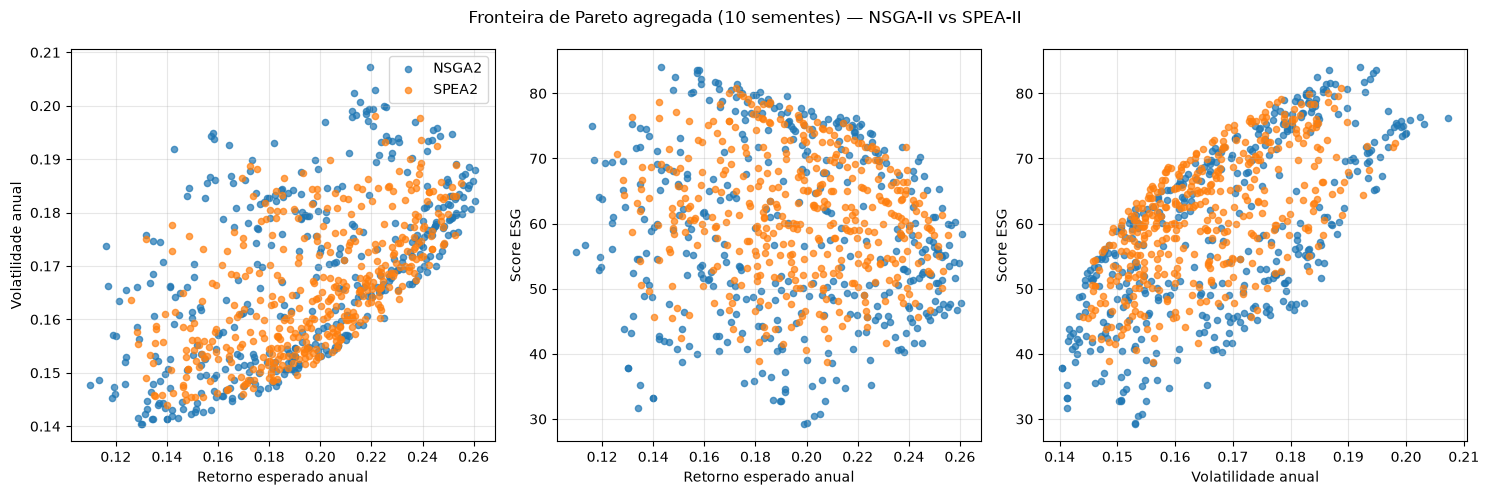

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for nome, tabela in tabelas_finais.items():
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=20, alpha=0.7, color=CORES_ALGORITMO[nome], label=nome)
for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
    ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle("Fronteira de Pareto agregada (10 sementes) — NSGA-II vs SPEA-II")
fig.tight_layout()
plt.show()


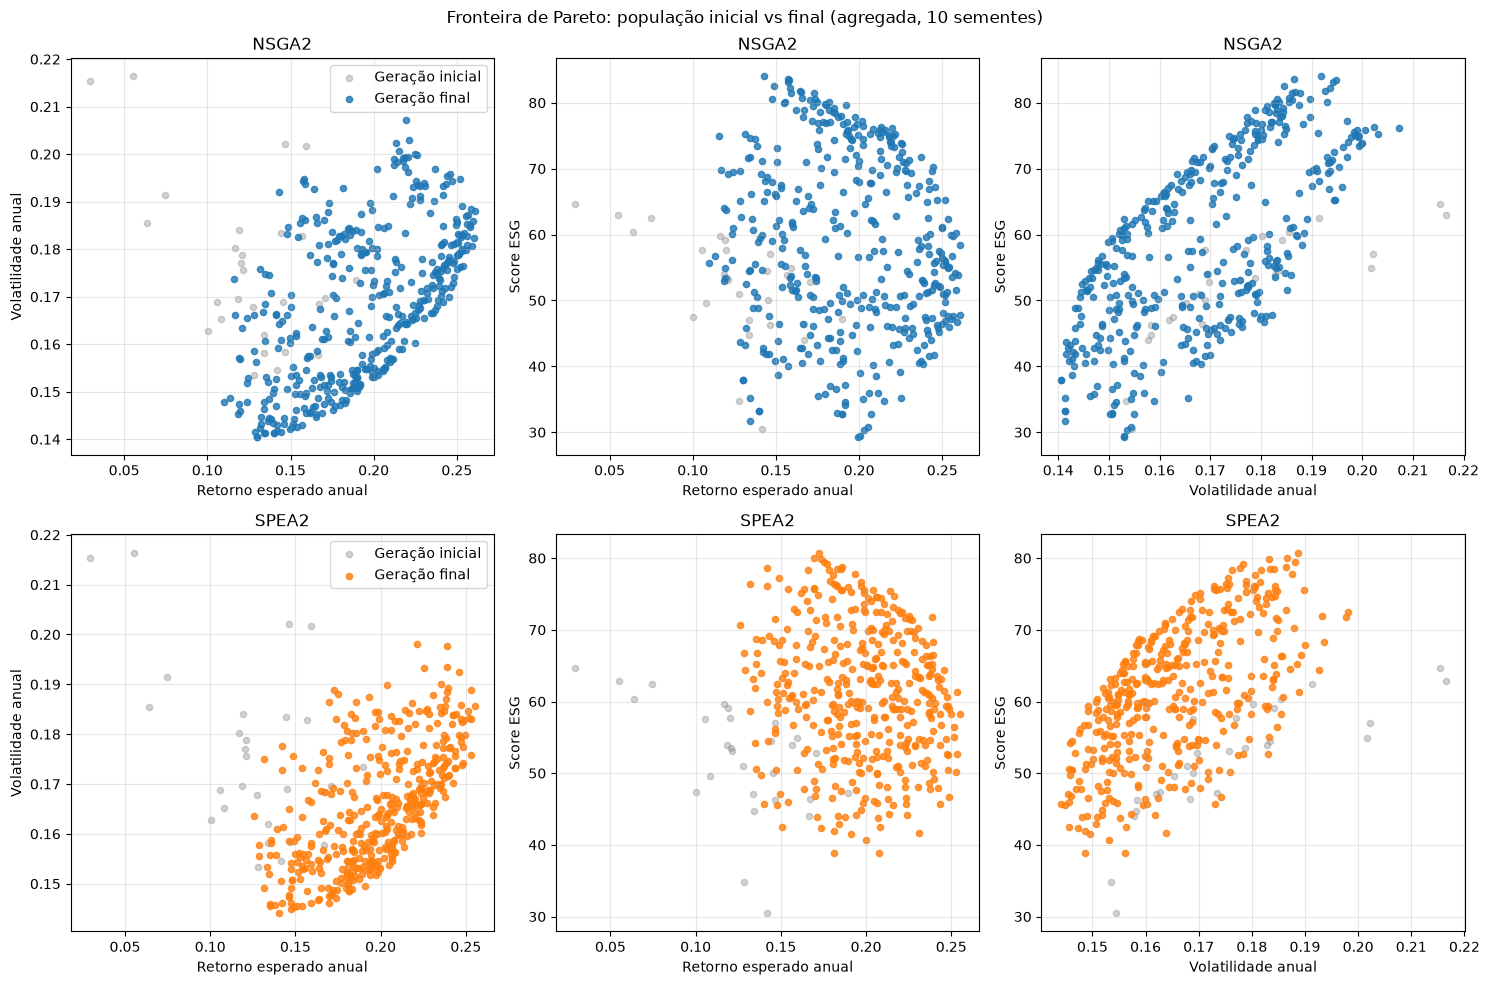

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for linha, nome in enumerate(ALGORITMOS_MOEA):
    for col, (x, y) in enumerate(PARES_OBJETIVOS):
        ax = axes[linha][col]
        ax.scatter(tabelas_iniciais[nome][x], tabelas_iniciais[nome][y], s=20, alpha=0.35, color="gray", label="Geração inicial")
        ax.scatter(tabelas_finais[nome][x], tabelas_finais[nome][y], s=20, alpha=0.8, color=CORES_ALGORITMO[nome], label="Geração final")
        ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.set_title(nome); ax.grid(alpha=0.3)
        if col == 0:
            ax.legend()
fig.suptitle("Fronteira de Pareto: população inicial vs final (agregada, 10 sementes)")
fig.tight_layout()
plt.show()


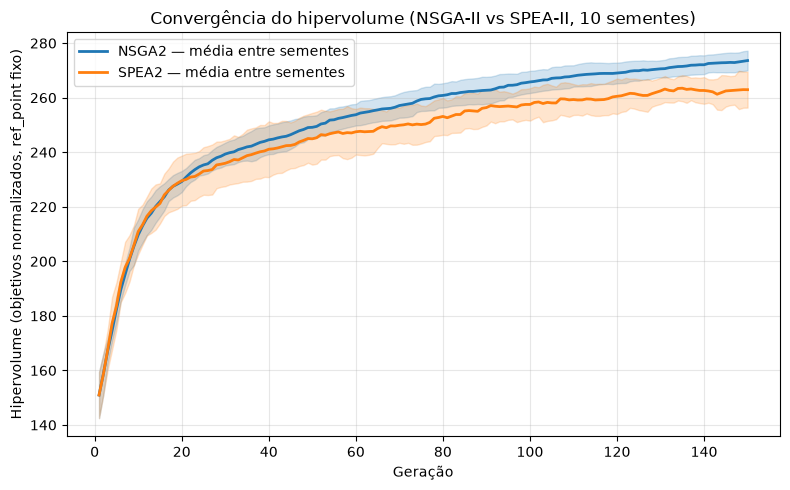

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
for nome, resultados in resultados_por_algoritmo.items():
    matriz = np.vstack([r.historico_hv for r in resultados])
    media, desvio = matriz.mean(axis=0), matriz.std(axis=0)
    geracoes = np.arange(1, matriz.shape[1] + 1)
    ax.plot(geracoes, media, color=CORES_ALGORITMO[nome], linewidth=2, label=f"{nome} — média entre sementes")
    ax.fill_between(geracoes, media - desvio, media + desvio, color=CORES_ALGORITMO[nome], alpha=0.2)
ax.set_xlabel("Geração"); ax.set_ylabel("Hipervolume (objetivos normalizados, ref_point fixo)")
ax.set_title("Convergência do hipervolume (NSGA-II vs SPEA-II, 10 sementes)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


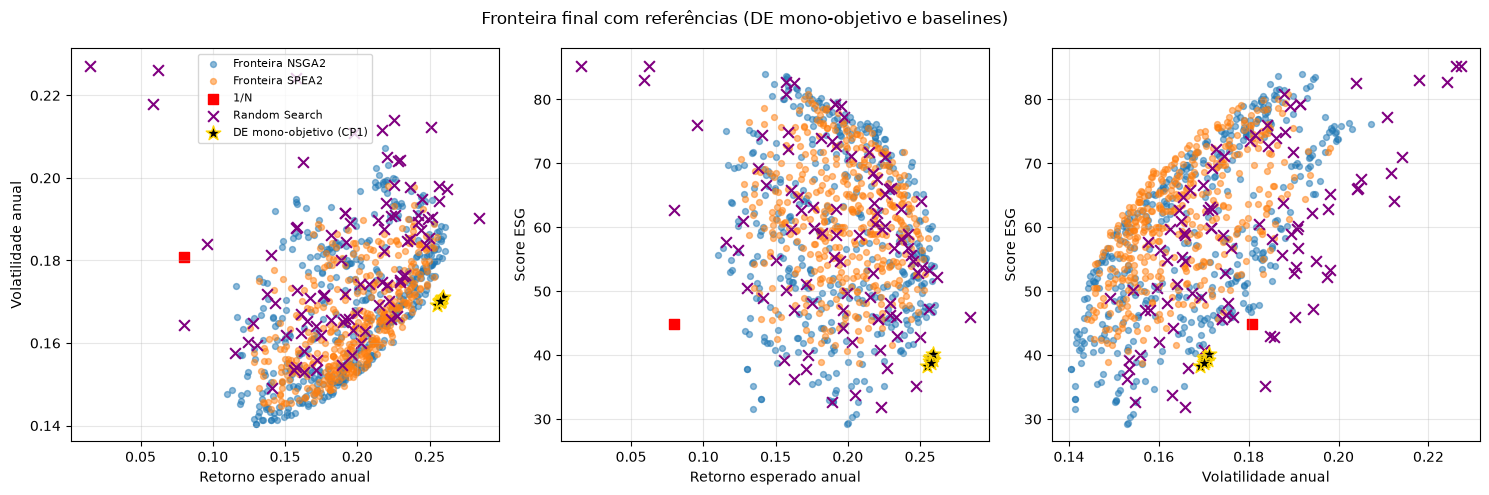

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for nome, tabela in tabelas_finais.items():
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=18, alpha=0.5, color=CORES_ALGORITMO[nome], label=f"Fronteira {nome}")

cores_baseline = {"1/N": "red", "Random Search": "purple"}
for nome_baseline, tabela in [("1/N", tabela_uniforme), ("Random Search", tabela_rs_nd)]:
    marker = "s" if nome_baseline == "1/N" else "x"
    for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
        ax.scatter(tabela[x], tabela[y], s=60, color=cores_baseline[nome_baseline], marker=marker, label=nome_baseline)

for ax, (x, y) in zip(axes, PARES_OBJETIVOS):
    ax.scatter(
        tabela_so_de[x], tabela_so_de[y], s=120, color="black", marker="*",
        edgecolors="gold", linewidths=1.0, label="DE mono-objetivo (CP1)",
    )
    ax.set_xlabel(ROTULOS[x]); ax.set_ylabel(ROTULOS[y]); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Fronteira final com referências (DE mono-objetivo e baselines)")
fig.tight_layout()
plt.show()


## 13. Discussão de trade-offs

Números computados nesta execução (médias entre as 10 sementes, salvo onde indicado):

| Algoritmo | HV médio por semente (±desvio) | não-dominadas por semente | HV da fronteira agregada (10 sementes) | soluções agregadas |
|---|---|---|---|---|
| NSGA-II | 273,61 (±3,81) | 100/100 | 288,15 | 409/1000 |
| SPEA-II | 262,93 (±6,93) | 100/100 | 276,77 | 412/1000 |

| Método | retorno | risco | Sharpe | score ESG |
|---|---|---|---|---|
| DE mono-objetivo (CP1) | 25,75% | 17,03% | 1,512 | 39,33 |
| Fronteira NSGA-II (média) | 19,37% | 16,83% | 1,149 | 58,51 |
| Fronteira SPEA-II (média) | 19,72% | 16,54% | 1,190 | 61,15 |

**NSGA-II e SPEA-II convergem para fronteiras semelhantes?** Sim, e de forma
muito próxima: os hipervolumes médios por semente diferem por 10,68 unidades
(273,61 vs 262,93, ou ~4%). O NSGA-II apresenta HV médio maior e variabilidade
menor (desvio 3,81 vs 6,93), sugerindo convergência mais estável. A fronteira
agregada do NSGA-II (HV=288,15, 409 soluções) domina levemente a do SPEA-II
(HV=276,77, 412 soluções).

**O ponto do DE mono-objetivo é dominado pela fronteira multiobjetivo?** Não —
em nenhuma das 10 sementes o ponto do DE é dominado por NSGA-II ou SPEA-II.
Isso é esperado: o DE otimiza risco-retorno de forma excelente (gap <0,2% do
ótimo exato do QP), mas ignora completamente o ESG. O ponto do DE fica no canto
da fronteira com máximo retorno e mínimo ESG — está sobre a fronteira eficiente
de risco-retorno, mas fora das soluções de compromisso entre os três objetivos.

**Trade-off retorno × ESG ao longo da fronteira.** O DE obtém retorno de 25,75%
com ESG médio de 39,33, enquanto a fronteira NSGA-II tem retorno médio de 19,37%
e ESG médio de 58,51 — ganho de ~19 pontos ESG ao custo de ~6,4 p.p. de retorno
esperado. Isso reflete a correlação positiva entre risco e ESG observada na
fronteira: ativos de maior score ESG tendem a ser de setores de menor volatilidade
(utilities, saúde), enquanto os de maior retorno esperado (commodities, petróleo)
têm ESG baixo.

**Evolução entre geração inicial e final.** A fronteira inicial (após a primeira
geração) tinha apenas 28 soluções não-dominadas por algoritmo. A fronteira final
agrega 409 (NSGA-II) e 412 (SPEA-II) soluções — expansão de ~14× — e todos os
pontos da fronteira inicial são dominados pela fronteira final. O HV cresce ~70%
entre a geração 1 e a geração 150, concentrando o ganho nas primeiras 30–50
gerações.

**Limitações.** (1) O vetor ESG é sintético, logo as
conclusões sobre trade-offs ESG devem ser interpretadas com cautela. (2) Testes
estatísticos (Mann-Whitney U com correção de Bonferroni): a diferença de HV entre NSGA-II e SPEA-II não é significativa na geração 50 (algoritmos ainda convergindo, p×3=1,00), mas torna-se significativa e de efeito grande a partir da geração 100 (p×3=0,0138, r_rb=0,76) e permanece na geração final (p×3=0,0030, r_rb=0,88). Isso indica que o NSGA-II converge para uma fronteira estatisticamente melhor que o SPEA-II no mesmo orçamento de avaliações.